### **OpenCLIP con Docker comparación XClip en Google Colab**

Este cuaderno implementa la línea base OpenCLIP usando frames representativos (Fase 1). Luego se extiende a una representación temporal basada en video usando un encoder preentrenado en Colab (Fase 2).

Se ha extraido un suboconjunto de 33 videos del dataset ActivityNet, con el cual se revisa recuperación y negativos difíciles y deja el pipeline automatizado en `scripts/` y `src/`.

#### **Flujo principal**
Se ha obtenido la selección de videos a traves de los scripts, con los siguientes pasos:
Toma cada segmento de ActivityNet (start, end, caption).
Extrae 5 frames uniformemente distribuidos dentro del segmento.
Guardar esos frames en JPG.
Crea un CSV con la ruta de cada frame y su caption asociado.

- 01_select_activitynet_subset.py  
- 02_select_listdownload.py        
- 03_build_activitynet_subset.py   
- 04_extract_segment_frames.py     

#### Fase 1: Preparación de datos y extracción de frames
### Pipeline de Recuperación Video-Texto con OpenCLIP

#### 1. Extracción de Frames

```text
ActivityNet Captions
(video_id, start, end, caption)
        │
        
Seleccionar segmento
[start, end]
        │
        
Muestreo uniforme
de 5 frames
        │
        
OpenCV VideoCapture
        │
        ▼
Frames JPG
        │
        
activitynet_frames.csv
(frame_path, caption, segment_id)
```

#### 2. Construcción de Embeddings

```text
activitynet_frames.csv
        │
        
Agrupar por
(video_id, segment_id)
        │
        
5 Frames del Segmento
        │
        
OpenCLIP Image Encoder
(ViT-B-32)
        │
        
Frame Embeddings
        │
        
Mean Pooling
        │
        
Segment Embedding
```

#### 3. Embeddings de Texto

```text
Caption
        │
        
OpenCLIP Text Encoder
        │
        
Text Embedding
```

#### 4. Almacenamiento

```text
Segment Embeddings
        │
       
Text Embeddings    Segment IDs
        │
        
activitynet_clip_embeddings.npz
```

Contenido del archivo:

* segment_features
* text_features
* segment_ids
* captions
* model_name
* pretrained

````


#### Resumen

Cada segmento de ActivityNet es representado mediante cinco frames extraídos uniformemente dentro de su intervalo temporal. Los frames son codificados mediante OpenCLIP (ViT-B-32) y sus embeddings son agregados utilizando mean pooling para obtener una representación única del segmento. Las descripciones textuales son codificadas por el encoder de texto de OpenCLIP. Finalmente, la similitud coseno entre embeddings visuales y textuales permite realizar la recuperación video-texto y evaluar el desempeño mediante Recall@1, Recall@5 y Mean Reciprocal Rank (MRR).


In [ ]:
#04_extract_segment_frames.py
from __future__ import annotations

import argparse
from pathlib import Path

import cv2
import pandas as pd
from tqdm import tqdm


def extract_frame_at_time(cap: cv2.VideoCapture, time_sec: float):
    cap.set(cv2.CAP_PROP_POS_MSEC, time_sec * 1000)
    success, frame = cap.read()

    if not success:
        return None

    return frame


def main():
    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--metadata-csv",
        default="data/activitynet/activitynet_subset.csv",
    )

    parser.add_argument(
        "--videos-dir",
        default="data/activitynet/videos",
    )

    parser.add_argument(
        "--frames-dir",
        default="data/activitynet/frames",
    )

    parser.add_argument(
        "--frames-per-segment",
        type=int,
        default=5,
    )

    parser.add_argument(
        "--output-csv",
        default="data/activitynet/activitynet_frames.csv",
    )

    args = parser.parse_args()

    metadata_csv = Path(args.metadata_csv)
    videos_dir = Path(args.videos_dir)
    frames_dir = Path(args.frames_dir)

    frames_dir.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(metadata_csv)

    records = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        video_file = row["video_file"]
        video_path = videos_dir / video_file

        if not video_path.exists():
            print(f"[WARN] No existe: {video_path}")
            continue

        start_time = float(row["start"])
        end_time = float(row["end"])

        duration = max(end_time - start_time, 0.01)

        cap = cv2.VideoCapture(str(video_path))

        if not cap.isOpened():
            print(f"[WARN] No se pudo abrir: {video_path}")
            continue

        for frame_idx in range(args.frames_per_segment):

            if args.frames_per_segment == 1:
                t = (start_time + end_time) / 2
            else:
                alpha = frame_idx / (args.frames_per_segment - 1)
                t = start_time + alpha * duration

            frame = extract_frame_at_time(cap, t)

            if frame is None:
                continue

            image_name = (
                f"{row['youtube_id']}"
                f"_seg{row['segment_id']}"
                f"_f{frame_idx}.jpg"
            )

            image_path = frames_dir / image_name

            cv2.imwrite(str(image_path), frame)

            records.append(
                {
                    "video_id": row["video_id"],
                    "youtube_id": row["youtube_id"],
                    "segment_id": row["segment_id"],
                    "start": start_time,
                    "end": end_time,
                    "caption": row["caption"],
                    "frame_idx": frame_idx,
                    "frame_path": str(image_path.resolve()),
                }
            )

        cap.release()

    out_df = pd.DataFrame(records)
    out_df.to_csv(args.output_csv, index=False)

    print()
    print("Frames extraídos:", len(out_df))
    print("CSV guardado en:", args.output_csv)


if __name__ == "__main__":
    main()

### **python scripts/04_extract_segment_frames.py \
  --metadata-csv data/activitynet/activitynet_subset.csv \
  --videos-dir data/activitynet/videos \
  --frames-dir data/activitynet/frames \
  --frames-per-segment 5 \
  --output-csv data/activitynet/activitynet_frames.csv

In [ ]:
#05_build_clip_embeddings
from __future__ import annotations

from pathlib import Path
import sys

PROJECT_ROOT = Path(__file__).resolve().parent.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import argparse
import numpy as np
import pandas as pd

from src.openclip_utils import (
    create_model,
    encode_image_paths,
    encode_texts,
)


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--frames-csv",
        default="data/activitynet/activitynet_frames.csv",
    )

    parser.add_argument(
        "--model-name",
        default="ViT-B-32",
    )

    parser.add_argument(
        "--pretrained",
        default="laion2b_s34b_b79k",
    )

    parser.add_argument(
        "--batch-size",
        type=int,
        default=16,
    )

    parser.add_argument(
        "--output",
        default="outputs/embeddings/activitynet_clip_embeddings.npz",
    )

    args = parser.parse_args()

    df = pd.read_csv(args.frames_csv)

    model, preprocess, tokenizer, device = create_model(
        args.model_name,
        args.pretrained,
    )

    segment_features = []
    segment_ids = []
    captions = []

    grouped = df.groupby(
        [
            "video_id",
            "segment_id",
        ]
    )

    for (video_id, segment_id), group in grouped:

        frame_paths = group["frame_path"].tolist()

        frame_embeddings = encode_image_paths(
            model,
            preprocess,
            frame_paths,
            device,
            batch_size=args.batch_size,
        )

        segment_embedding = frame_embeddings.mean(axis=0)

        segment_features.append(segment_embedding)

        segment_ids.append(
            f"{video_id}_seg{segment_id}"
        )

        captions.append(
            group.iloc[0]["caption"]
        )

    segment_features = np.vstack(segment_features)

    text_features = encode_texts(
        model,
        tokenizer,
        captions,
        device,
        batch_size=max(args.batch_size, 32),
    )

    output_path = Path(args.output)
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    np.savez_compressed(
        output_path,
        segment_features=segment_features,
        text_features=text_features,
        segment_ids=np.array(segment_ids),
        captions=np.array(captions),
        model_name=args.model_name,
        pretrained=args.pretrained,
    )

    print()
    print("Embeddings guardados en:")
    print(output_path)

    print()
    print("Segmentos:", len(segment_ids))
    print("Textos:", len(captions))
    print("Dimensión:", segment_features.shape[1])


if __name__ == "__main__":
    main()

root@08ad89565310:/workspace/Semana4/ProyectoFinal# python scripts/05_build_clip_embeddings.py
open_clip_pytorch_model.bin: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 605M/605M [01:04<00:00, 9.40MB/s]

Embeddings guardados en:
outputs/embeddings/activitynet_clip_embeddings.npz

Segmentos: 109
Textos: 109
Dimensión: 512

#### **Matriz de similitud y métricas de retrieval**
### Evaluación Inicial de Recuperación Temporal (`eval_temporal_retrieval_inicial.py`)

Una vez generados los embeddings visuales de los segmentos y los embeddings de texto mediante OpenCLIP, se realiza una evaluación de recuperación video-texto.

El script carga el archivo `activitynet_clip_embeddings.npz`, que contiene:

* Embeddings de segmentos (`segment_features`)
* Embeddings de texto (`text_features`)
* Identificadores de segmentos
* Descripciones asociadas

A continuación, se construye una matriz de similitud utilizando el producto punto entre embeddings de texto y embeddings de segmentos:

```text
Text Features
        │
        
Similarity Matrix
        
        │
Segment Features
```

Cada fila de la matriz representa una consulta textual y cada columna un segmento de video candidato.

Para cada consulta se ordenan los segmentos según su similitud y se verifica la posición ocupada por el segmento correcto dentro del ranking.

Las métricas utilizadas son:

* **Recall@1 (R@1):** porcentaje de consultas cuyo segmento correcto aparece en la primera posición.
* **Recall@5 (R@5):** porcentaje de consultas cuyo segmento correcto aparece dentro de los cinco primeros resultados.
* **Recall@10 (R@10):** porcentaje de consultas cuyo segmento correcto aparece dentro de los diez primeros resultados.
* **Mean Reciprocal Rank (MRR):** promedio del inverso de la posición del segmento correcto en el ranking.

El flujo completo de evaluación es:

```text
activitynet_clip_embeddings.npz
        │
        
Segment Features
+
Text Features
        │
        
Similarity Matrix
(text × segment)
        │
        
Ranking de Segmentos
        │
        
R@1
R@5
R@10

        │
        
activitynet_retrieval_metrics.json
```

Finalmente, las métricas calculadas se almacenan en el archivo:

```text
outputs/metrics/activitynet_retrieval_metrics.json
```

permitiendo cuantificar la capacidad de OpenCLIP para recuperar correctamente segmentos de video a partir de consultas textuales.


In [ ]:
#06_eval_temporal_retrieval.py
from __future__ import annotations

import argparse
import json
from pathlib import Path

import numpy as np
import pandas as pd

def recall_at_k(similarity, k):
    hits = 0

    for i in range(similarity.shape[0]):
        ranking = np.argsort(-similarity[i])

        if i in ranking[:k]:
            hits += 1

    return hits / similarity.shape[0]


def mean_reciprocal_rank(similarity):
    scores = []

    for i in range(similarity.shape[0]):
        ranking = np.argsort(-similarity[i])

        rank = np.where(ranking == i)[0][0] + 1

        scores.append(1.0 / rank)

    return float(np.mean(scores))

def build_top5_results(
    similarity,
    captions,
    segment_ids,
):

    rows = []

    for i in range(similarity.shape[0]):

        ranking = np.argsort(-similarity[i])

        top5 = ranking[:5]

        row = {
            "query_caption": captions[i],
            "correct_segment": segment_ids[i],
        }

        for j, idx in enumerate(top5):

            row[f"top{j+1}_segment"] = segment_ids[idx]
            row[f"top{j+1}_score"] = float(
                similarity[i, idx]
            )

        rows.append(row)

    return pd.DataFrame(rows)

def build_hard_negatives(
    similarity,
    captions,
    segment_ids,
):

    rows = []

    for i in range(similarity.shape[0]):

        ranking = np.argsort(-similarity[i])

        for idx in ranking:

            if idx != i:

                rows.append(
                    {
                        "query_caption": captions[i],
                        "correct_segment": segment_ids[i],
                        "hard_negative_segment": segment_ids[idx],
                        "similarity": float(
                            similarity[i, idx]
                        ),
                    }
                )

                break

    return pd.DataFrame(rows)

def main():

    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--embeddings",
        default="outputs/embeddings/activitynet_clip_embeddings.npz",
    )

    parser.add_argument(
        "--output-json",
        default="outputs/metrics/activitynet_retrieval_metrics.json",
    )

    args = parser.parse_args()

    bundle = np.load(
        args.embeddings,
        allow_pickle=True,
    )

    segment_features = bundle["segment_features"]
    text_features = bundle["text_features"]

    segment_ids = bundle["segment_ids"]
    captions = bundle["captions"]

    similarity = text_features @ segment_features.T

    metrics = {
        "R@1": recall_at_k(similarity, 1),
        "R@5": recall_at_k(similarity, 5),
        "R@10": recall_at_k(similarity, 10),
        "MRR": mean_reciprocal_rank(similarity),
    }

    output_json = Path(args.output_json)

    output_json.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    with open(output_json, "w") as f:
        json.dump(metrics, f, indent=2)

    top5_df = build_top5_results(
        similarity,
        captions,
        segment_ids,
    )

    top5_csv = (
        output_json.parent /
        "activitynet_top5.csv"
    )

    top5_df.to_csv(
        top5_csv,
        index=False,
    )

    hard_df = build_hard_negatives(
        similarity,
        captions,
        segment_ids,
    )

    hard_csv = (
        output_json.parent /
        "activitynet_hard_negatives.csv"
    )

    hard_df.to_csv(
        hard_csv,
        index=False,
    )

    print()
    print(json.dumps(metrics, indent=2))

    print()
    print("Top5:", top5_csv)

    print("Hard negatives:", hard_csv)


if __name__ == "__main__":
    main()

Resultados
{
  "R@1": 0.22935779816513763,
  "R@5": 0.7155963302752294,
  "R@10": 0.8165137614678899,
  "MRR": 0.4306722689669618
}

### Ejemplos de Hard Negatives

Durante la evaluación se identificaron segmentos incorrectos que presentan una alta similitud semántica con la consulta textual. Estos ejemplos permiten analizar los casos más difíciles para el modelo.

| Consulta                                    | Segmento Correcto  | Hard Negative      | Similitud |
| ------------------------------------------- | ------------------ | ------------------ | --------- |
| We see two people playing foosball.         | v_28GYivx4lyk_seg0 | v_28GYivx4lyk_seg1 | 0.335     |
| A man puts his face in front of the camera. | v_28GYivx4lyk_seg2 | v_arTumJHoLB0_seg1 | 0.293     |
| The men cuts the top of the hedge.          | v_2ErgL7-MXHw_seg1 | v_2ErgL7-MXHw_seg2 | 0.355     |

Estos casos muestran que OpenCLIP puede asignar puntuaciones altas a segmentos visualmente similares, incluso cuando no corresponden exactamente a la descripción consultada.


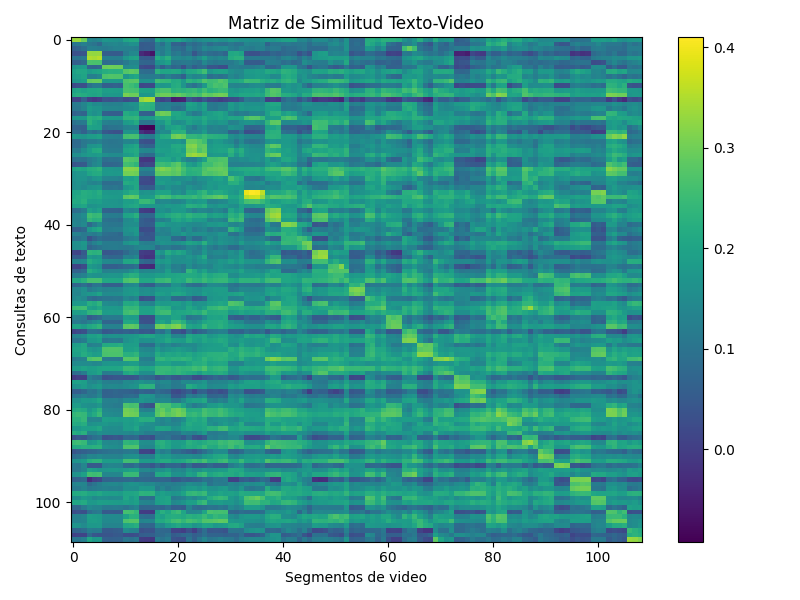